# Main Pipeline FFNN
Pipeline ini berisi alur lengkap dari baca dataset sampai prediksi (tanpa EDA/feature engineering lanjutan):
1. Load data
2. Split train/val/test
3. Build config + model
4. Training
5. Evaluasi dan prediksi
6. Save/load model

# Import library

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from modules.config import ModelConfig
from modules.ffnn import FFNN
from modules.activationfunction import Linear, Sigmoid, ReLU, Tanh, Softmax
from modules.lossfunction import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from modules.weightinit import ZerosInitializer, RandomUniformInitializer, RandomNormalInitializer
from utils.model_io import save_model, load_model
from utils.visualization import plot_gradient_distribution, plot_weight_distribution

# Params

In [7]:
DATA_PATH = Path('../datasetml_2026.csv')
TARGET_COL = 'placement_status'

TEST_SIZE = 0.20
VAL_SIZE = 0.20
RANDOM_STATE = 42

DEFAULT_HIDDEN_DIMS = [32, 16]
DEFAULT_HIDDEN_ACTIVATIONS = ['ReLU', 'ReLU']
DEFAULT_OUTPUT_ACTIVATION = 'Sigmoid'
DEFAULT_LOSS = 'BinaryCrossEntropy'

DEFAULT_INITIALIZER = 'RandomNormalInitializer'
DEFAULT_INITIALIZER_PARAMS = {'mean': 0.0, 'variance': 0.01, 'seed': RANDOM_STATE}

MODEL_PARAMS = {
    'learning_rate': 0.001,
    'epochs': 100,
    'batch_size': 32,
    'verbose': 1,
    'regularization': 'l2',
    'reg_lambda': 0.01,
    'random_state': RANDOM_STATE,
}

HIDDEN_DIMS = DEFAULT_HIDDEN_DIMS
HIDDEN_ACTIVATION_CLASSES = DEFAULT_HIDDEN_ACTIVATIONS
OUTPUT_ACTIVATION_CLASS = DEFAULT_OUTPUT_ACTIVATION
LOSS_CLASS = DEFAULT_LOSS
INITIALIZER_CLASS = DEFAULT_INITIALIZER
INITIALIZER_PARAMS = DEFAULT_INITIALIZER_PARAMS

MODEL_PATH = Path('../models/ffnn_placement.pkl')
RUN_MODE = 1  # 1 = train, 2 = load

In [8]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)

X_df = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# one hot encoding for cat features
X_df = pd.get_dummies(X_df, drop_first=False)

label_map = {'Not Placed': 0, 'Placed': 1}

y_cat = y_raw 
y_all = y_raw.map(label_map).to_numpy(dtype=np.float64).reshape(-1, 1)

X_all = X_df.to_numpy(dtype=np.float64)
print('Feature matrix shape:', X_all.shape)
print('Target shape:', y_all.shape)

Dataset shape: (10000, 12)
Feature matrix shape: (10000, 28)
Target shape: (10000, 1)


In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cat
)

strat_train = y_train_full.ravel()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat_train
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (6400, 28) (6400, 1)
Val  : (1600, 28) (1600, 1)
Test : (2000, 28) (2000, 1)


In [10]:
if RUN_MODE == 1:
    # Build activation objects from configured class names.
    activation_class_map = {
        'Linear': Linear,
        'Sigmoid': Sigmoid,
        'ReLU': ReLU,
        'Tanh': Tanh,
        'Softmax': Softmax,
    }

    if any(name not in activation_class_map for name in HIDDEN_ACTIVATION_CLASSES):
        raise ValueError(f"Unknown hidden activations: {HIDDEN_ACTIVATION_CLASSES}")
    if OUTPUT_ACTIVATION_CLASS not in activation_class_map:
        raise ValueError(f"Unknown output activation: {OUTPUT_ACTIVATION_CLASS}")

    # Loss
    if LOSS_CLASS == 'MSE':
        loss_fn = MSE()
    elif LOSS_CLASS == 'BinaryCrossEntropy':
        loss_fn = BinaryCrossEntropy()
    elif LOSS_CLASS == 'CategoricalCrossEntropy':
        loss_fn = CategoricalCrossEntropy()
    else:
        raise ValueError(f"Unknown loss class: {LOSS_CLASS}")

    # Initializer
    if INITIALIZER_CLASS == 'ZerosInitializer':
        initializer = ZerosInitializer(**INITIALIZER_PARAMS)
    elif INITIALIZER_CLASS == 'RandomUniformInitializer':
        initializer = RandomUniformInitializer(**INITIALIZER_PARAMS)
    elif INITIALIZER_CLASS == 'RandomNormalInitializer':
        initializer = RandomNormalInitializer(**INITIALIZER_PARAMS)
    else:
        raise ValueError(f"Unknown initializer: {INITIALIZER_CLASS}")

    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    layers_dims = [input_dim] + HIDDEN_DIMS + [output_dim]

    hidden_activation_fns = [activation_class_map[name]() for name in HIDDEN_ACTIVATION_CLASSES]
    output_activation_fn = activation_class_map[OUTPUT_ACTIVATION_CLASS]()
    activation_fns = hidden_activation_fns + [output_activation_fn]

    config = ModelConfig(
        layers_dims=layers_dims,
        activation_fn=activation_fns,
        loss_fn=loss_fn,
        **MODEL_PARAMS
    )

    model = FFNN(config, initializer)
    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    history
else:
    model = load_model(MODEL_PATH)
    history = None
    print('Loaded model from:', MODEL_PATH)

Training: 100%|██████████| 100/100 [00:04<00:00, 22.10it/s, train_loss=0.5408, val_loss=0.5421]


In [11]:
y_test_pred = model.forward(X_test)

y_true_label = y_test.ravel().astype(int)
y_pred_label = (y_test_pred.ravel() >= 0.5).astype(int)

print('Accuracy:', round(accuracy_score(y_true_label, y_pred_label), 4))
print('Confusion Matrix:\n', confusion_matrix(y_true_label, y_pred_label))
print(classification_report(y_true_label, y_pred_label))

Accuracy: 0.733
Confusion Matrix:
 [[ 339  430]
 [ 104 1127]]
              precision    recall  f1-score   support

           0       0.77      0.44      0.56       769
           1       0.72      0.92      0.81      1231

    accuracy                           0.73      2000
   macro avg       0.74      0.68      0.68      2000
weighted avg       0.74      0.73      0.71      2000



In [12]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if RUN_MODE == 1:
    save_model(model, MODEL_PATH)
    print('Model saved to:', MODEL_PATH)

Model saved to: ..\models\ffnn_placement.pkl


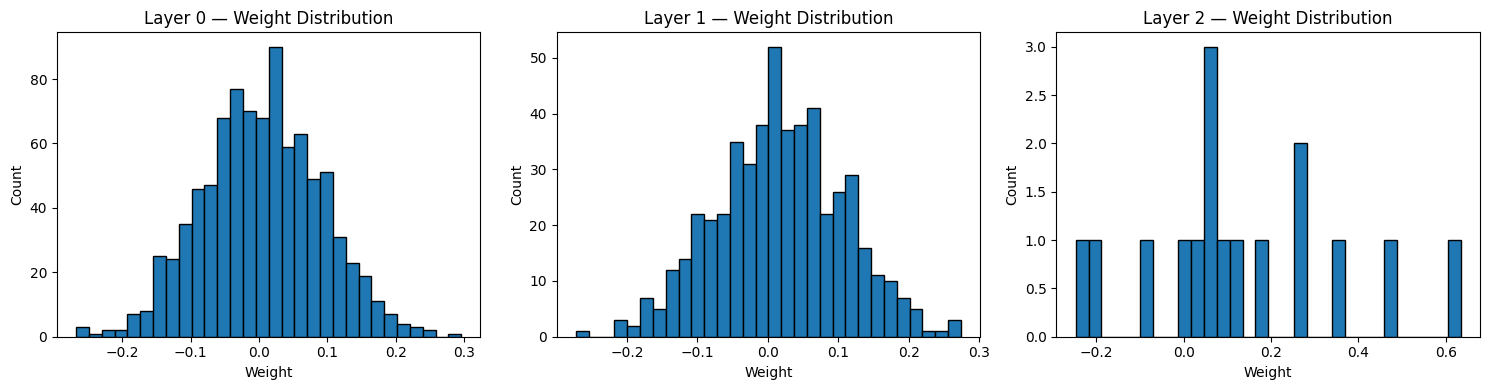

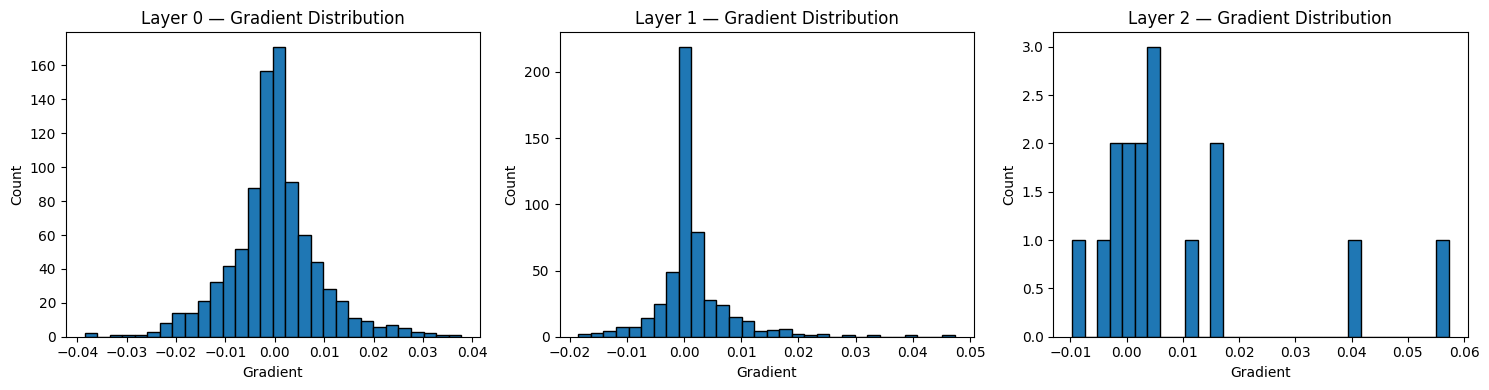

In [13]:
plot_weight_distribution(model)
plot_gradient_distribution(model)